<a href="https://colab.research.google.com/github/hannahishimwe/colab_projects/blob/main/notebooks/langchain_rag.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%pip install --quiet --upgrade langchain-text-splitters langchain-community langgraph

In [ ]:
pip install -qU "langchain[google-genai]"

In [ ]:
import getpass
import os

if not os.environ.get("GOOGLE_API_KEY"):
  os.environ["GOOGLE_API_KEY"] = getpass.getpass("Enter API key for Google Gemini: ")

from langchain.chat_models import init_chat_model
from langchain_google_genai import GoogleGenerativeAIEmbeddings

llm = init_chat_model("gemini-2.0-flash", model_provider="google_genai")

embeddings = GoogleGenerativeAIEmbeddings(model="models/embedding-001")

In [ ]:
pip install -qU langchain-google-genai langchain-core

In [ ]:
from langchain_core.vectorstores import InMemoryVectorStore

vector_store = InMemoryVectorStore(embeddings)

Initial input:
You start with a state that contains just the question:
{"question": "When was Nike founded?"}

Step 1 — retrieve:
Adds "context" (relevant documents) to the state:
{"question": "...", "context": [...]}

Step 2 — generate:
Uses question + context, and adds "answer":
{"question": "...", "context": [...], "answer": "..."}

/usr/local/lib/python3.11/dist-packages/langsmith/client.py:272: LangSmithMissingAPIKeyWarning: API key must be provided when using hosted LangSmith API
  warnings.warn(


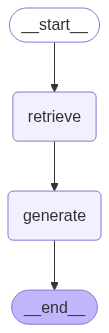

In [ ]:
import bs4
from langchain import hub
from langchain_community.document_loaders import WebBaseLoader
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import START, StateGraph
from typing_extensions import List, TypedDict

# Load and chunk contents of the blog
loader = WebBaseLoader(
    web_paths=("https://www.infosys.com/",),
    # bs_kwargs=dict(
    #     parse_only=bs4.SoupStrainer(
    #         class_=("post-content", "post-title", "post-header")
    #     )
    # ), - infosys website does not use these HTML class names
)
docs = loader.load()

text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
all_splits = text_splitter.split_documents(docs)

# Index chunks
_ = vector_store.add_documents(documents=all_splits)

# Define prompt for question-answering
# N.B. for non-US LangSmith endpoints, you may need to specify
# api_url="https://api.smith.langchain.com" in hub.pull.
"""
Usually a prompt like:
Use the following context to answer the question:
{context}

Question: {question}
Answer:
"""
prompt = hub.pull("rlm/rag-prompt")


# Define state for application
class State(TypedDict):
    question: str
    context: List[Document]
    answer: str


# Define application steps
def retrieve(state: State):
    retrieved_docs = vector_store.similarity_search(state["question"])
    return {"context": retrieved_docs}


def generate(state: State):
    # Joins all page contents from each doc in the list from the returned context into one string
    docs_content = "\n\n".join(doc.page_content for doc in state["context"])
    messages = prompt.invoke({"question": state["question"], "context": docs_content})
    response = llm.invoke(messages)
    return {"answer": response.content}


# Compile application and test
graph_builder = StateGraph(State).add_sequence([retrieve, generate])
graph_builder.add_edge(START, "retrieve")
graph = graph_builder.compile()
graph

In [ ]:
response = graph.invoke({"question": "What is Infosys?"})
print(response["answer"])

Infosys is a company that provides consulting, IT services, and digital transformation solutions. They offer services across various industries and have platforms like Infosys Equinox and Infosys Wingspan. The company also focuses on empowering talent transformations and has a knowledge institute.


In [ ]:
print(f'Context: {response["context"]}\n\n')

Context: [Document(id='79165984-a1cc-4599-bc11-6463c7eb6b48', metadata={'source': 'https://www.infosys.com/', 'title': 'Infosys - Consulting | IT Services | Digital Transformation', 'description': 'Infosys is a global leader in next-generation digital services and consulting.', 'language': 'en'}, page_content="Infosys - Consulting | IT Services | Digital Transformation\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n \n\n \n\n\n\n Navigate your next \n Infosys Knowledge Institute \n Investors \n Careers \n\n\n\n\n\n\n\n\n\nsearch\n\n\n\ncross\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nSearch\nHit enter to search or ESC to close\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n   \n\n Navigate your\r\n                                next   \n Industries\r\n                                  \n Services   \n Platform

In [ ]:
#This code allows you to see the steps of the Graph in real time!

for step in graph.stream(
    {"question": "What is Infosys?"}, stream_mode="updates"
):
    print(f"{step}\n\n----------------\n")


{'retrieve': {'context': [Document(id='79165984-a1cc-4599-bc11-6463c7eb6b48', metadata={'source': 'https://www.infosys.com/', 'title': 'Infosys - Consulting | IT Services | Digital Transformation', 'description': 'Infosys is a global leader in next-generation digital services and consulting.', 'language': 'en'}, page_content="Infosys - Consulting | IT Services | Digital Transformation\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n \n\n \n\n\n\n Navigate your next \n Infosys Knowledge Institute \n Investors \n Careers \n\n\n\n\n\n\n\n\n\nsearch\n\n\n\ncross\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nSearch\nHit enter to search or ESC to close\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n   \n\n Navigate your\r\n                                next   \n Industries\r\n                                  \n Servic

In [ ]:
# Make up my own custom template

from langchain_core.prompts import PromptTemplate

template = """Use the following pieces of context to answer the question at the end.
If you don't know the answer, just say that you don't know, don't try to make up an answer.
Use three sentences maximum and keep the answer as concise as possible.
Always say "thanks for asking!" at the end of the answer.

{context}

Question: {question}

Helpful Answer:"""
custom_rag_prompt = PromptTemplate.from_template(template)

def retrieve(state: State):
    retrieved_docs = vector_store.similarity_search(state["question"])
    return {"context": retrieved_docs}


def generate(state: State):
    # Joins all page contents from each doc in the list from the returned context into one string
    docs_content = "\n\n".join(doc.page_content for doc in state["context"])
    messages = custom_rag_prompt.invoke({"question": state["question"], "context": docs_content})
    response = llm.invoke(messages)
    return {"answer": response.content}


# Compile application and test
graph_builder = StateGraph(State).add_sequence([retrieve, generate])
graph_builder.add_edge(START, "retrieve")
graph = graph_builder.compile()

response = graph.invoke({"question": "What is Infosys?"})
print(response["answer"])

Infosys is a consulting, IT services, and digital transformation company. They offer services, platforms, and knowledge through the Infosys Knowledge Institute. They also focus on empowering talent transformations and digital core capabilities. Thanks for asking!


In [ ]:
"""
Split up documents into beginning, middle and end
"""

total_documents = len(all_splits)
third = total_documents // 3

for i, document in enumerate(all_splits):
    if i < third:
        document.metadata["section"] = "beginning"
    elif i < 2 * third:
        document.metadata["section"] = "middle"
    else:
        document.metadata["section"] = "end"


all_splits[0].metadata

{'source': 'https://www.infosys.com/',
 'title': 'Infosys - Consulting | IT Services | Digital Transformation',
 'description': 'Infosys is a global leader in next-generation digital services and consulting.',
 'language': 'en',
 'section': 'beginning'}

In [ ]:
# new vector store

from langchain_core.vectorstores import InMemoryVectorStore

vector_store = InMemoryVectorStore(embeddings)
_ = vector_store.add_documents(all_splits)

Defining what a search query is:

Defined here as a query and a section of the webpage, but can be customised further

... - shows field is required
e.g. "Search query to run" is metadata

A query is a required string

A section is a required Literal out of three options

In [ ]:
from typing import Literal

from typing_extensions import Annotated


class Search(TypedDict):
    """Search query."""

    query: Annotated[str, ..., "Search query to run."]
    section: Annotated[
        Literal["beginning", "middle", "end"],
        ...,
        "Section to query.",
    ]

Analyse query does the following:

e.g.
query = structured_llm.invoke("Show me what Infosys says at the start")
- takes free text question

- Output might be:

{
  "query": "Infosys company overview",
  "section": "beginning"
}

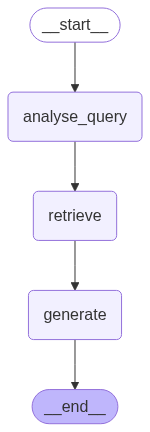

In [ ]:
# Update previous graph

class State(TypedDict):
    question: str
    query: Search # now states know about a query
    context: List[Document]
    answer: str

"""
Take this user question and extract or reformat it into the Search structure — with query and section fields.
"""
def analyse_query(state: State):
    structured_llm = llm.with_structured_output(Search) # ensures the llm follows the schema defined by Search
    query = structured_llm.invoke(state["question"])
    return {"query": query}


def retrieve(state: State):
    query = state["query"]
    retrieved_docs = vector_store.similarity_search(
        query["query"],
        filter=lambda doc: doc.metadata.get("section") == query["section"], #filters all documents returned from the similarity search, to ensure they belong to correct section
    )
    return {"context": retrieved_docs}


def generate(state: State):
    docs_content = "\n\n".join(doc.page_content for doc in state["context"])
    messages = prompt.invoke({"question": state["question"], "context": docs_content})
    response = llm.invoke(messages)
    return {"answer": response.content}


graph_builder = StateGraph(State).add_sequence([analyse_query, retrieve, generate])
graph_builder.add_edge(START, "analyse_query")
graph = graph_builder.compile()
graph

In [ ]:
for step in graph.stream(
    {"question": "What investor information is listed at the end of the website?"},
    stream_mode="updates",
):
    print(f"{step}\n\n----------------\n")

{'analyse_query': {'query': {'query': 'investor information', 'section': 'end'}}}

----------------

{'retrieve': {'context': [Document(id='f45fedc7-49f9-4d5a-b7b9-51eae6168a74', metadata={'source': 'https://www.infosys.com/', 'title': 'Infosys - Consulting | IT Services | Digital Transformation', 'description': 'Infosys is a global leader in next-generation digital services and consulting.', 'language': 'en', 'section': 'end'}, page_content='Connect with us\n\n    \n    \n    \n    \n\n\n\n\n\n\n\n\nCopyright © 2025 Infosys Limited\n\n\n\n\n Select\r\n                  Country/region \n\n\nAustralia \nAustria \nBelgium \nBrazil \nBulgaria \nCanada \nChile \nChina \nCosta\r\n                      Rica\nCroatia \nCzech \nDenmark \nEstonia \nFinland \nFrance \nGermany \nHong\r\n                      Kong\nHungary \nIndia \nIreland \nItaly \nJapan \nLiechtenstein \nLatvia \nLithuania \nLuxembourg \nMalaysia \nMauritius \nMexico \nNew\r\n                      Zealand\nNorway \nPeru \nPhili

In [ ]:
#reinstalling dependencies

%%capture --no-stderr
%pip install --upgrade --quiet langgraph langchain-community beautifulsoup4

The Tool decorator makes the tool's output to include both:

"content" – the main textual output (e.g. a message or answer)

"artifact" – structured or downloadable content (e.g. file, chart, image, JSON object)

This retrieve function returns the main string of a document source and its content related to the query, and then also the actual documents as the artifact

In [ ]:
from langchain_core.tools import tool


@tool(response_format="content_and_artifact")
def retrieve(query: str):
    """Retrieve information related to a query."""
    retrieved_docs = vector_store.similarity_search(query, k=10)
    serialized = "\n\n".join(
        (f"Source: {doc.metadata}\n" f"Content: {doc.page_content}")
        for doc in retrieved_docs
    )
    return serialized, retrieved_docs

##New Langgraph


In [ ]:
from langgraph.graph import MessagesState, StateGraph

graph_builder = StateGraph(MessagesState)

In [ ]:
from langchain_core.messages import SystemMessage
from langgraph.prebuilt import ToolNode


# Step 1: Generate an AIMessage that may include a tool-call to be sent.
def query_or_respond(state: MessagesState):
    """Generate tool call for retrieval or respond."""
    llm_with_tools = llm.bind_tools([retrieve]) #wrap the llm to have access to a tool too
    response = llm_with_tools.invoke(state["messages"])
    # we use MessagesState because it keeps a history of messages, each time a new one generated it is appended instead of overwrites
    return {"messages": [response]} # we'll have a long history each time


# Step 2: Execute the retrieval.
"""
Passing [retrieve] means this node can execute the retrieve tool when triggered.
This node can be added to a LangChain graph to integrate tool calls into the workflow.
"""
tools = ToolNode([retrieve])


# Step 3: Generate a response using the retrieved content.
def generate(state: MessagesState):
    """Generate answer."""
    # Get generated ToolMessages
    recent_tool_messages = []
    for message in reversed(state["messages"]): # most recent call to last
        if message.type == "tool":
            recent_tool_messages.append(message)
        else:
            break
    tool_messages = recent_tool_messages[::-1] #reverse again

    # Format into prompt
    docs_content = "\n\n".join(doc.content for doc in tool_messages)
    system_message_content = (
        "You are an assistant for question-answering tasks. "
        "Use the following pieces of retrieved context to answer "
        "the question. When generating a search query for the retrieval tool, be specific and include keywords related to what the user is asking for."
        "If you don't know the answer, consider synonyms of keywords. For example, a synonym of motto is tagline so the answer would be similar. Use three sentences maximum and keep the "
        "answer concise."
        "\n\n"
        f"{docs_content}"
    )
    conversation_messages = [
        message
        for message in state["messages"]
        if message.type in ("human", "system")
        or (message.type == "ai" and not message.tool_calls)
    ] #filters out previous message history to just human, system or non-tool call messages
    prompt = [SystemMessage(system_message_content)] + conversation_messages #concatenates this message generated plus the message history to handle

    # Run
    response = llm.invoke(prompt)
    return {"messages": [response]}

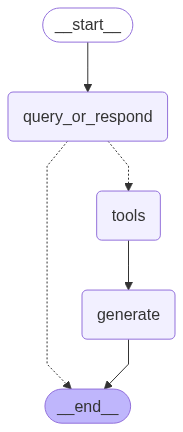

In [ ]:
from langgraph.graph import END
from langgraph.prebuilt import ToolNode, tools_condition

graph_builder.add_node(query_or_respond)
graph_builder.add_node(tools)
graph_builder.add_node(generate)

graph_builder.set_entry_point("query_or_respond")
graph_builder.add_conditional_edges(
    "query_or_respond",
    tools_condition, #if a tool call was needed go to "tools" state, else go to END state, checks last message
    {END: END, "tools": "tools"},
)
graph_builder.add_edge("tools", "generate")
graph_builder.add_edge("generate", END)

graph = graph_builder.compile()
graph

#Test

In [ ]:
input_message = "Hello"

for step in graph.stream(
    {"messages": [{"role": "user", "content": input_message}]},
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

Hello
================================== Ai Message ==================================

Hello! How can I help you today?


In [ ]:
input_message = "What is Infosys"

for step in graph.stream(
    {"messages": [{"role": "user", "content": input_message}]},
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

What is Infosys
================================== Ai Message ==================================
Tool Calls:
  retrieve (95badef0-4dc9-4a2e-a6ee-29a7c1b5800b)
 Call ID: 95badef0-4dc9-4a2e-a6ee-29a7c1b5800b
  Args:
    query: What is Infosys
================================= Tool Message =================================
Name: retrieve

Source: {'source': 'https://www.infosys.com/', 'title': 'Infosys - Consulting | IT Services | Digital Transformation', 'description': 'Infosys is a global leader in next-generation digital services and consulting.', 'language': 'en', 'section': 'end'}
Content: View All













Careers
Every Infoscion is the navigator
          of our clients’ digital transformation





  
Life at Infosys

What our people say

  "I'm most excited about the
                  opportunity to grow
                  at Infosys." 
                  - Danielle, Infosys Indiana 
  "I joined In

In [ ]:
input_message = "What is their motto"

for step in graph.stream(
    {"messages": [{"role": "user", "content": input_message}]},
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

What is their motto
================================== Ai Message ==================================

I need more information to answer. Who are you asking about? Please provide more context or specify who you are referring to.


In [ ]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()
graph = graph_builder.compile(checkpointer=memory)

# Specify an ID for the thread
config = {"configurable": {"thread_id": "abc123"}}

In [ ]:
input_message = "What is infosys"

for step in graph.stream(
    {"messages": [{"role": "user", "content": input_message}]},
    stream_mode="values",
    config=config, #include the config which stores thread
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

What is infosys
================================== Ai Message ==================================
Tool Calls:
  retrieve (f1864b69-39a2-491d-810c-12a1c4202781)
 Call ID: f1864b69-39a2-491d-810c-12a1c4202781
  Args:
    query: what is infosys
================================= Tool Message =================================
Name: retrieve

Source: {'source': 'https://www.infosys.com/', 'title': 'Infosys - Consulting | IT Services | Digital Transformation', 'description': 'Infosys is a global leader in next-generation digital services and consulting.', 'language': 'en', 'section': 'end'}
Content: Connect with us

    
    
    
    








Copyright © 2025 Infosys Limited




 Select
                  Country/region 


Australia 
Austria 
Belgium 
Brazil 
Bulgaria 
Canada 
Chile 
China 
Costa
                      Rica
Croatia 
Czech 
Denmark 
Estonia 
Finland 
France 
Germany 
Hong
                      Kong

In [ ]:
input_message = "What is their motto"

for step in graph.stream(
    {"messages": [{"role": "user", "content": input_message}]},
    stream_mode="values",
    config=config, #include the config which stores thread
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

What is their motto
================================== Ai Message ==================================
Tool Calls:
  retrieve (5f2ed784-00d1-49ae-b420-771fbf6afacc)
 Call ID: 5f2ed784-00d1-49ae-b420-771fbf6afacc
  Args:
    query: What is Infosys motto
================================= Tool Message =================================
Name: retrieve

Source: {'source': 'https://www.infosys.com/', 'title': 'Infosys - Consulting | IT Services | Digital Transformation', 'description': 'Infosys is a global leader in next-generation digital services and consulting.', 'language': 'en', 'section': 'beginning'}
Content: Infosys - Consulting | IT Services | Digital Transformation
























































































 

 



 Navigate your next 
 Infosys Knowledge Institute 
 Investors 
 Careers 









search



cross






















Search
Hit enter to search 

#Using an agent instead of a chain

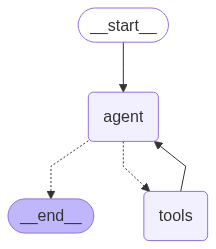

In [ ]:
from langgraph.prebuilt import create_react_agent

agent_executor = create_react_agent(llm, [retrieve], checkpointer=memory)
agent_executor

In [ ]:
config = {"configurable": {"thread_id": "def234"}}

input_message = (
    "what can infosys help me navigate?"
)

for event in agent_executor.stream(
    {"messages": [{"role": "user", "content": input_message}]},
    stream_mode="values",
    config=config,
):
    event["messages"][-1].pretty_print()

================================ Human Message =================================

what can infosys help me navigate?
================================== Ai Message ==================================
Tool Calls:
  retrieve (068f4f20-9577-42fc-9c9c-29758419fc21)
 Call ID: 068f4f20-9577-42fc-9c9c-29758419fc21
  Args:
    query: What can Infosys help me navigate?
================================= Tool Message =================================
Name: retrieve

Source: {'source': 'https://www.infosys.com/', 'title': 'Infosys - Consulting | IT Services | Digital Transformation', 'description': 'Infosys is a global leader in next-generation digital services and consulting.', 'language': 'en', 'section': 'end'}
Content: View All













Careers
Every Infoscion is the navigator
          of our clients’ digital transformation





  
Life at Infosys

What our people say

  "I'm most excited about the
                  opportunity to grow
                  at Infosys." 
                  - Dan